# COSC 325 – Introduction to Machine Learning, Spring 2026
## Final Project: STUDENT PERFORMANCE PREDICTION

**Student Names:** Kaitlin Sloan, Praneetha Voona, Manihams Suraparaju, 
Joshua Grewe, Justin Gurki


---

# Part 1- Data Loading and Preproccessing

In [213]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (semicolon-separated)
data = pd.read_csv("student/student-mat.csv", sep=";")
data.columns = data.columns.str.strip()

data.columns
data.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## Step 1: Check to make sure the dataset has no missing values and is clean:

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


<Axes: xlabel='G3', ylabel='count'>

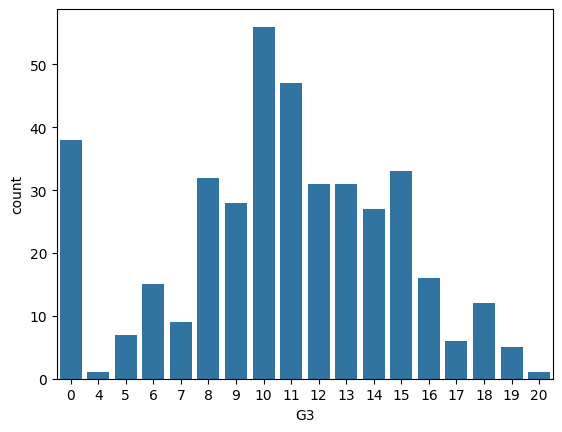

In [214]:
print(data.isnull().sum())
data.describe()
sns.countplot(x=data["G3"])


The output of data.isnull().sum() shows that every column has 0 missing values. This confirms that the dataset is already clean and we can proceed with preprocessing.
The Above graph shows the disrebution of values that exist.


## Step 2: Create Pass/Fail Label and drop G1 and G2

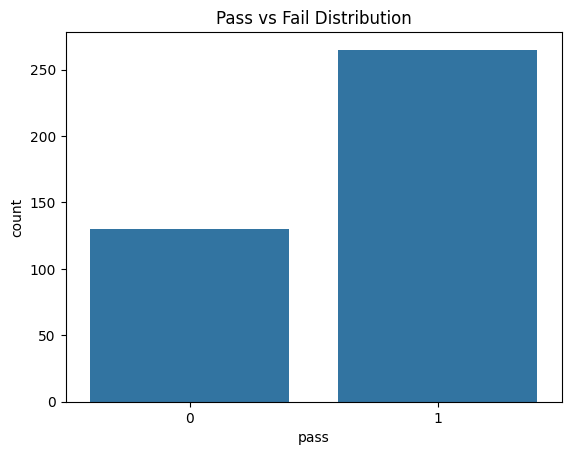

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G3', 'pass'],
      dtype='object')


In [215]:
data["pass"] = (data["G3"] >= 10).astype(int)
plt.clf()
sns.countplot(x=data["pass"])
plt.title("Pass vs Fail Distribution")

plt.show()

#drop g1 and g2
data_no_leak = data.drop(columns=["G1", "G2"])
print(data_no_leak.columns)


## Step 3: Build Preproccessing Pipeline and TrainTest Split + Logistic Regression

In [216]:
# define features and label first so column lists match the feature dataframe
X = data_no_leak.drop(columns=["pass"])
y = data_no_leak["pass"]

# derive categorical/numeric column lists from X (not from data_no_leak) so they match
catagorical = X.select_dtypes(include="object").columns
numeric = X.select_dtypes(include=["int64", "float64"]).columns

# ensure OneHotEncoder ignores unknown categories in test set
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), catagorical),
        ("num", StandardScaler(), numeric),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train_prep = preprocess.fit_transform(X_train)
X_test_prep = preprocess.transform(X_test)

logreg = LogisticRegression(max_iter=500)
logreg.fit(X_train_prep, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Step 5: Evaluate Baseline Model

F1 Score: 0.9346
ROC-AUC: 0.9790

Confusion Matrix (raw counts):
[[22  4]
 [ 3 50]]


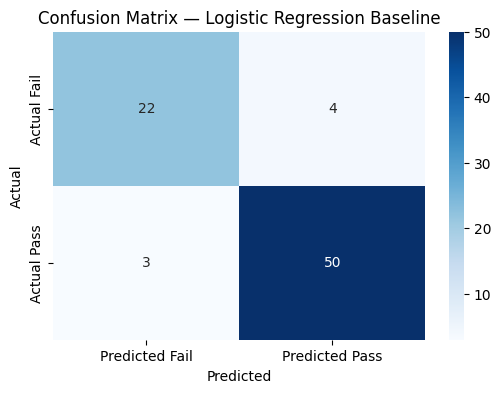

In [217]:
preds = logreg.predict(X_test_prep)
probs = logreg.predict_proba(X_test_prep)[:, 1]

# Scores
f1 = f1_score(y_test, preds)
roc = roc_auc_score(y_test, probs)

print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc:.4f}")
print("\nConfusion Matrix (raw counts):")
print(confusion_matrix(y_test, preds))

# Pretty confusion matrix
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Fail", "Predicted Pass"],
            yticklabels=["Actual Fail", "Actual Pass"])
plt.title("Confusion Matrix — Logistic Regression Baseline")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# Part 2 - Random Forest Pipeline

In [218]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

Load dataset (semicolon-separated)

In [219]:
data = pd.read_csv("student/student-mat.csv", sep=";")
data.columns = data.columns.str.strip()

# Step 1: Create Pass/Fail Label and drop G1, G2, AND G3

In [220]:
data["pass"] = (data["G3"] >= 10).astype(int)

Drop G1, G2, and G3 to prevent data leakage (since pass is based on G3)

In [221]:
data_no_leak = data.drop(columns=["G1", "G2", "G3"])
print("Features used for training:")
print(data_no_leak.columns)

Features used for training:
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'pass'],
      dtype='object')


Since the dataset uses a numeric grade for G3, we first convert it into a binary pass/fail label using a cutoff of 10, which is the standard passing threshold in the Portuguese school system. We also make sure to drop G1 and G2 alongside G3 — we caught early on that leaving those in would basically be giving the model the answer, since they're just earlier grades for the same class.

# Step 2: Build Preprocessing Pipeline and Train/Test Split

Define features and label

In [222]:
X = data_no_leak.drop(columns=["pass"])
y = data_no_leak["pass"]

Derive categorical/numeric column lists from X

In [223]:
categorical = X.select_dtypes(include="object").columns
numeric = X.select_dtypes(include=["int64", "float64"]).columns

preprocess = ColumnTransformer(
transformers=[
("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical),
("num", StandardScaler(), numeric),
]
)

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, stratify=y, random_state=42
)

Preprocess the data

In [224]:
X_train_prep = preprocess.fit_transform(X_train)
X_test_prep = preprocess.transform(X_test)

Extract feature names for the importance plot later

In [225]:
cat_feature_names = preprocess.named_transformers_["cat"].get_feature_names_out(categorical)
feature_names = np.concatenate([cat_feature_names, numeric])

We set up a preprocessing pipeline to handle the mix of categorical and numeric features in the dataset. Categorical columns get One-Hot Encoded and numeric ones are standardized, then we do an 80/20 train/test split with stratification so the pass/fail ratio stays consistent between both sets.

# Step 3: Train Random Forest with Stratified 5-fold CV & Hyperparameter Tuning

In [226]:
rf = RandomForestClassifier(random_state=42)

param_grid = {
'n_estimators': [50, 100, 200],
'max_depth': [None, 5, 10, 15],
'min_samples_split': [2, 5, 10],
'min_samples_leaf': [1, 2, 4]
}

Stratified 5-fold CV optimizing for F1-score

In [227]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=1)

print("Starting Grid Search CV...")
grid_search.fit(X_train_prep, y_train)

best_rf = grid_search.best_estimator_
print(f"Best Hyperparameters: {grid_search.best_params_}")

Starting Grid Search CV...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Hyperparameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 50}


Instead of just going with default settings, we ran a grid search over several hyperparameters like tree depth, number of estimators, and minimum samples per leaf to find the best combination. We used Stratified 5-Fold CV with F1-score as the target metric since we wanted the model to perform well across both classes, not just the majority one.

# Step 4: Evaluate Tuned Model

In [228]:
preds = best_rf.predict(X_test_prep)
probs = best_rf.predict_proba(X_test_prep)[:, 1]

Scores

In [229]:
f1 = f1_score(y_test, preds)
roc = roc_auc_score(y_test, probs)

print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, preds))

F1 Score: 0.7705
ROC-AUC: 0.6067

Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.15      0.22        26
           1       0.68      0.89      0.77        53

    accuracy                           0.65        79
   macro avg       0.54      0.52      0.50        79
weighted avg       0.59      0.65      0.59        79



Pretty confusion matrix

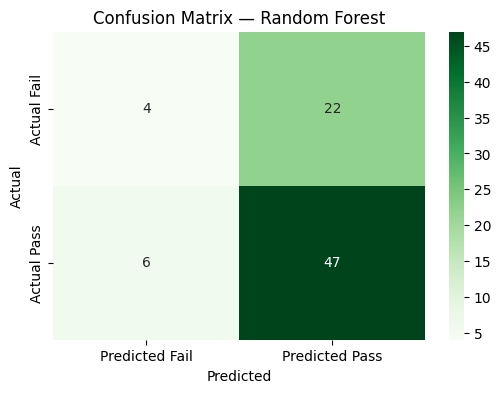

In [230]:
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
xticklabels=["Predicted Fail", "Predicted Pass"],
yticklabels=["Actual Fail", "Actual Pass"])
plt.title("Confusion Matrix — Random Forest")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

We evaluated the best model on the test set using F1-score and ROC-AUC to get a sense of both its precision-recall balance and overall classification ability. We also plotted a confusion matrix to see exactly where the model was getting things right or wrong in terms of pass/fail predictions.


# Step 5: Plot Feature Importances (Gini-Based)

In [231]:
importances =best_rf.feature_importances_

Create a DataFrame and sort

In [232]:
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False)

Plot top 15 features

C:\Users\joshu\AppData\Local\Temp\ipykernel_12356\1377271843.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df.head(15), palette='viridis')


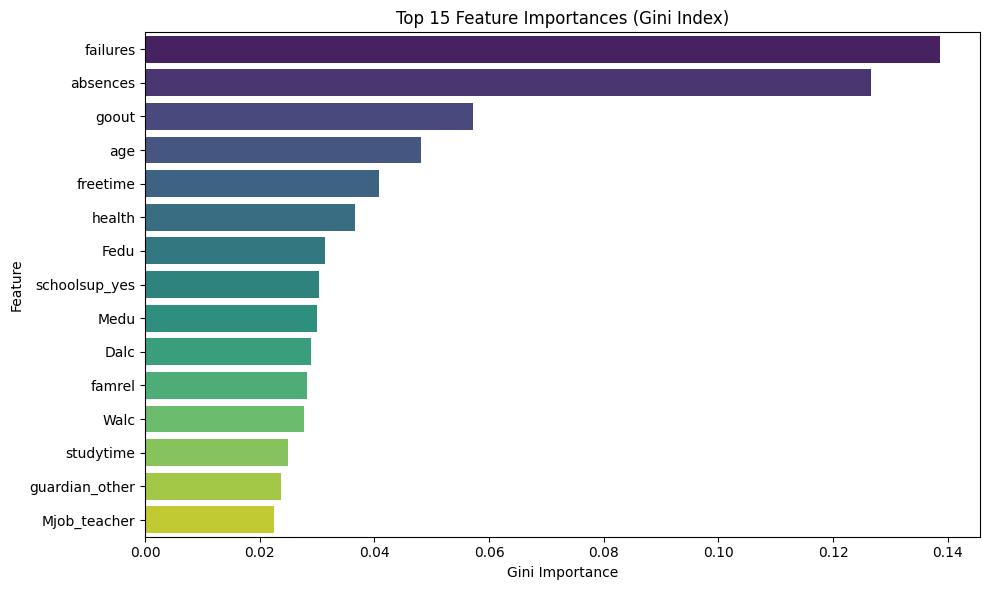

In [233]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df.head(15), palette='viridis')
plt.title('Top 15 Feature Importances (Gini Index)')
plt.xlabel('Gini Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

To get a better understanding of what the model actually learned, we pulled the Gini-based feature importances from the trained Random Forest and plotted the top 15. This helped us see which features — whether behavioral, demographic, or school-related — ended up being the most useful for predicting whether a student would pass.

# Part 3 - Gradient Boosting Pipeline

In [234]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [235]:
data = pd.read_csv("student/student-mat.csv", sep=";")
data.columns = data.columns.str.strip()

# Step 1: Create two sets one with G1/G2 and one without

In [236]:
data["pass"] = (data["G3"] >= 10).astype(int)

In [237]:
data_with_grades = data.drop(columns=["G3"])
data_no_grades = data.drop(columns=["G1", "G2", "G3"])

print("Features used for training with G1/G2:")
print(data_with_grades.columns)
print("Features used for training without G1/G2:")
print(data_no_grades.columns)

#data_no_leak = data.drop(columns=["G1", "G2", "G3"])
#print("Features used for training:")
#print(data_no_leak.columns)

Features used for training with G1/G2:
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'pass'],
      dtype='object')
Features used for training without G1/G2:
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'pass'],
      dtype='object')


# Step 2: Create a function to run the XGB pipeline

In [238]:
def run_xgb_pipeline(data):

    X = data.drop(columns=["pass"])
    y = data["pass"]

    categorical = X.select_dtypes(include="object").columns
    numeric = X.select_dtypes(include=["int64", "float64"]).columns

    preprocess = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical),
            ("num", StandardScaler(), numeric),
        ]
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    X_train_prep = preprocess.fit_transform(X_train)
    X_test_prep = preprocess.transform(X_test)

    xgb = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    )

    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 15],
        'learning_rate': [0.01, 0.1],
        'subsample': [0.8, 1.0]
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=1)
    grid_search.fit(X_train_prep, y_train)

    best_model = grid_search.best_estimator_

    preds = best_model.predict(X_test_prep)
    probs = best_model.predict_proba(X_test_prep)[:, 1]

    f1 = f1_score(y_test, preds)
    roc = roc_auc_score(y_test, probs)
    cm = confusion_matrix(y_test, preds)

    return f1, roc, cm, preds, y_test


# Step 3: Run the pipeline and evaluate the results

In [239]:
f1_no, roc_no, cm_no, preds_no, y_test_no = run_xgb_pipeline(data_no_grades)

print(f"F1 Score: {f1_no:.4f}")
print(f"ROC-AUC: {roc_no:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, preds))

f1_yes, roc_yes, cm_yes, preds_yes, y_test_yes = run_xgb_pipeline(data_with_grades)

print(f"F1 Score: {f1_yes:.4f}")
print(f"ROC-AUC: {roc_yes:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, preds))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
F1 Score: 0.7840
ROC-AUC: 0.6248

Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.15      0.22        26
           1       0.68      0.89      0.77        53

    accuracy                           0.65        79
   macro avg       0.54      0.52      0.50        79
weighted avg       0.59      0.65      0.59        79

Fitting 5 folds for each of 36 candidates, totalling 180 fits
F1 Score: 0.9200
ROC-AUC: 0.9419

Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.15      0.22        26
           1       0.68      0.89      0.77        53

    accuracy                           0.65        79
   macro avg       0.54      0.52      0.50        79
weighted avg       0.59      0.65      0.59        79



# Step 4: Evaluate the confusion matrices

--- XGBoost without G1/G2 ---
F1 Score: 0.784
ROC_AUC: 0.6248185776487664


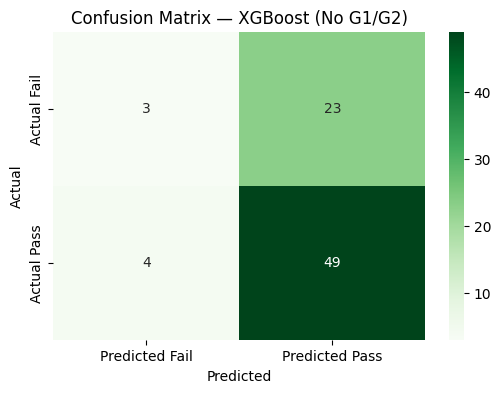

In [240]:
print("--- XGBoost without G1/G2 ---")

print(f"F1 Score: {f1_no}")
print(f"ROC_AUC: {roc_no}")

plt.figure(figsize=(6,4))
sns.heatmap(cm_no, annot=True, fmt="d", cmap="Greens",
    xticklabels=["Predicted Fail", "Predicted Pass"],
    yticklabels=["Actual Fail", "Actual Pass"])
plt.title("Confusion Matrix — XGBoost (No G1/G2)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

--- XGBoost with G1/G2 ---
F1 Score: 0.92
ROC_AUC: 0.941944847605225


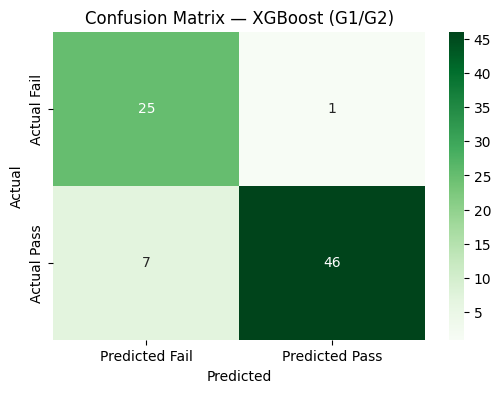

In [241]:
print("--- XGBoost with G1/G2 ---")

print(f"F1 Score: {f1_yes}")
print(f"ROC_AUC: {roc_yes}")

plt.figure(figsize=(6,4))
sns.heatmap(cm_yes, annot=True, fmt="d", cmap="Greens",
    xticklabels=["Predicted Fail", "Predicted Pass"],
    yticklabels=["Actual Fail", "Actual Pass"])
plt.title("Confusion Matrix — XGBoost (G1/G2)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()